# 📘 Assignment 11: PCA on Manufacturing 6G Dataset

## 🧠 Objective
Understand how PCA reduces dimensionality and helps interpret machine behavior.

## 📦 Step 0: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## 📂 Step 1: Load Dataset

In [2]:
df = pd.read_csv("manufacturing_6G_dataset.csv")
df.head()

,Timestamp,Machine_ID,Operation_Mode,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%,Efficiency_Status
0,2024-01-01 00:00:00,39,Idle,74.137590,3.500595,8.612162,10.650542,0.207764,7.751261,477.657391,0.344650,14.965470,Low
1,2024-01-01 00:01:00,29,Active,84.264558,3.355928,2.268559,29.111810,2.228464,4.989172,398.174747,0.769848,7.678270,Low
2,2024-01-01 00:02:00,15,Active,44.280102,2.079766,6.144105,18.357292,1.639416,0.456816,108.074959,0.987086,8.198391,Low
3,2024-01-01 00:03:00,43,Active,40.568502,0.298238,4.067825,29.153629,1.161021,4.582974,329.579410,0.983390,2.740847,Medium
4,2024-01-01 00:04:00,8,Idle,75.063817,0.345810,6.225737,34.029191,4.796520,2.287716,159.113525,0.573117,12.100686,Low


## 🔢 Step 2: Select Features

In [3]:
features = [
    'Temperature_C', 'Vibration_Hz', 'Power_Consumption_kW',
    'Network_Latency_ms', 'Packet_Loss_%',
    'Quality_Control_Defect_Rate_%',
    'Production_Speed_units_per_hr',
    'Predictive_Maintenance_Score',
    'Error_Rate_%'
]

X = df[features]

## ⚖️ Step 3: Standardization

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 🔄 Step 4: Apply PCA

In [6]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

## 🧾 Step 5: Create PCA DataFrame

In [7]:
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Efficiency_Status'] = df['Efficiency_Status']
pca_df.head()

,PC1,PC2,Efficiency_Status
0,1.991559,-0.877431,Low
1,0.703815,-0.215785,Low
2,0.309520,-0.287968,Low
3,-0.060464,0.853378,Medium
4,-0.724822,-1.044957,Low


## 📊 Step 6: Visualization

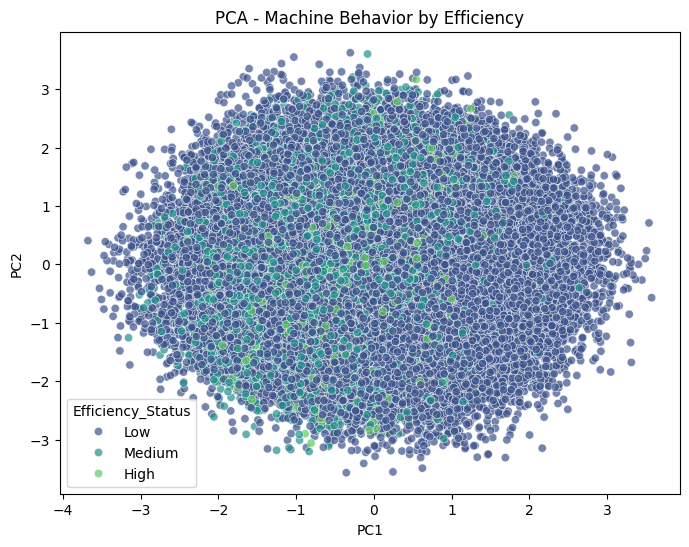

In [8]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Efficiency_Status',
    data=pca_df,
    palette='viridis',
    alpha=0.7
)

plt.title("PCA - Machine Behavior by Efficiency")
plt.show()

## 📈 Step 7: Explained Variance

In [9]:
print("Variance per component:", pca.explained_variance_ratio_)
print("Total variance captured:", sum(pca.explained_variance_ratio_))

Variance per component: [0.11280493 0.11222922]
Total variance captured: 0.22503414664209212


## 🧠 Step 8: Loadings

In [10]:
loadings = pd.DataFrame(
    pca.components_,
    columns=features,
    index=['PC1', 'PC2']
)

print(loadings)

     Temperature_C  Vibration_Hz  Power_Consumption_kW  Network_Latency_ms  \
PC1      -0.073682      0.388031              0.213921            0.283927   
PC2      -0.438015      0.008739             -0.426994            0.539397   

     Packet_Loss_%  Quality_Control_Defect_Rate_%  \
PC1      -0.376405                      -0.153709   
PC2      -0.415217                       0.212593   

     Production_Speed_units_per_hr  Predictive_Maintenance_Score  Error_Rate_%  
PC1                       0.460624                      0.314921      0.490885  
PC2                      -0.176251                     -0.271838     -0.110597  


## 🔍 Step 9: Sorted Loadings

In [11]:
print(loadings.T.sort_values(by='PC1', key=np.abs, ascending=False))
print(loadings.T.sort_values(by='PC2', key=np.abs, ascending=False))

                                    PC1       PC2
Error_Rate_%                   0.490885 -0.110597
Production_Speed_units_per_hr  0.460624 -0.176251
Vibration_Hz                   0.388031  0.008739
Packet_Loss_%                 -0.376405 -0.415217
Predictive_Maintenance_Score   0.314921 -0.271838
Network_Latency_ms             0.283927  0.539397
Power_Consumption_kW           0.213921 -0.426994
Quality_Control_Defect_Rate_% -0.153709  0.212593
Temperature_C                 -0.073682 -0.438015
                                    PC1       PC2
Network_Latency_ms             0.283927  0.539397
Temperature_C                 -0.073682 -0.438015
Power_Consumption_kW           0.213921 -0.426994
Packet_Loss_%                 -0.376405 -0.415217
Predictive_Maintenance_Score   0.314921 -0.271838
Quality_Control_Defect_Rate_% -0.153709  0.212593
Production_Speed_units_per_hr  0.460624 -0.176251
Error_Rate_%                   0.490885 -0.110597
Vibration_Hz                   0.388031  0.008739


## 📉 Step 10: Scree Plot

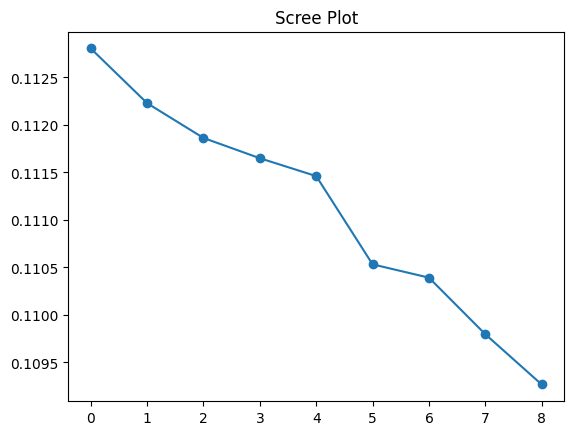

In [12]:
pca_full = PCA()
pca_full.fit(X_scaled)

plt.plot(pca_full.explained_variance_ratio_, marker='o')
plt.title("Scree Plot")
plt.show()

In [ ]:
PC1 having higher values for below 
•	Temperature 
•	Power 
•	Vibration 
 PC2 having higher value for 
•	Latency 
•	Packet Loss 
so PC1 = Machine Stress / Load
PC2 = Network/System Issues

